#**IMPORT LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

#**LOAD DATASET**

In [2]:
Heart_Disease = pd.read_csv('heart.csv')

#**View First 10 Rows**

In [3]:
print(Heart_Disease.head(10))

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   
5   39   M           NAP        120          339          0     Normal    170   
6   45   F           ATA        130          237          0     Normal    170   
7   54   M           ATA        110          208          0     Normal    142   
8   37   M           ASY        140          207          0     Normal    130   
9   48   F           ATA        120          284          0     Normal    120   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1     

#**DATASET SIZE**

In [4]:
print(Heart_Disease.shape)

(918, 12)


The Dataset has 918 rows and 12 columns.

#**COLUMN NAMES**

In [5]:
print(Heart_Disease.columns)

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')


#**DATA TYPES AND NULL VALUES**

In [6]:
print(Heart_Disease.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None


The dataset contains 918 rows and 12 columns of medical data. The dataset contains no missing values across the mixture of integer, decimal, and categorical data types.

#**CHECKING MISSING VALUES**

In [7]:
print(Heart_Disease.isnull().sum())


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


The dataset has no missing values.

#**CHECKING DUPLICATE**

In [8]:
print(Heart_Disease.duplicated().sum())

0


The dataset has no duplicated rows

#**Summary Statistics**

In [9]:
print(Heart_Disease.describe())

              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.396514   198.799564    0.233115  136.809368   
std      9.432617   18.514154   109.384145    0.423046   25.460334   
min     28.000000    0.000000     0.000000    0.000000   60.000000   
25%     47.000000  120.000000   173.250000    0.000000  120.000000   
50%     54.000000  130.000000   223.000000    0.000000  138.000000   
75%     60.000000  140.000000   267.000000    0.000000  156.000000   
max     77.000000  200.000000   603.000000    1.000000  202.000000   

          Oldpeak  HeartDisease  
count  918.000000    918.000000  
mean     0.887364      0.553377  
std      1.066570      0.497414  
min     -2.600000      0.000000  
25%      0.000000      0.000000  
50%      0.600000      1.000000  
75%      1.500000      1.000000  
max      6.200000      1.000000  


*Summary statistics for categorical variables*

In [10]:
print(Heart_Disease.describe(include=['object']))

        Sex ChestPainType RestingECG ExerciseAngina ST_Slope
count   918           918        918            918      918
unique    2             4          3              2        3
top       M           ASY     Normal              N     Flat
freq    725           496        552            547      460


This output displays the summary statistics for the 5 categorical variables in the dataset, including counts, unique categories, the most frequent value, and its occurrence frequency. For example, it highlights that "M" is the dominant category for Sex (725 out of 918 entries) and "Normal" is the most common RestingECG result.

#**VALIDATING BINARY VARIABLES**

In [11]:
print(Heart_Disease['Sex'].value_counts())
print(Heart_Disease['HeartDisease'].value_counts())
print(Heart_Disease['FastingBS'].value_counts())
print(Heart_Disease['ExerciseAngina'].value_counts())

Sex
M    725
F    193
Name: count, dtype: int64
HeartDisease
1    508
0    410
Name: count, dtype: int64
FastingBS
0    704
1    214
Name: count, dtype: int64
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64


Binary Variables Validation was performed to confirm that the binary variables containd only their expected categories. This ensures the dataset is consistent before encoding.

#**EXPLORATORY DATA ANALYSIS**

#*HEART DISEASE DISTRIBUTION*

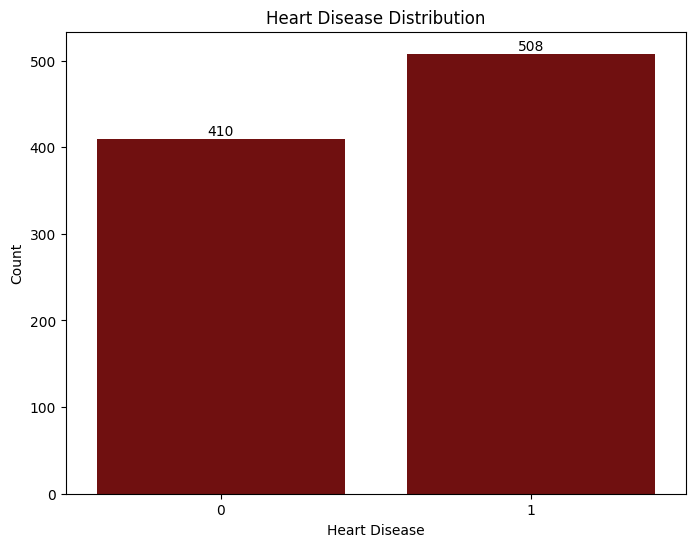

In [12]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='HeartDisease', data=Heart_Disease, color = 'maroon')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Heart Disease Distribution')
plt.xlabel('Heart Disease')
plt.ylabel('Count')
plt.show()

410 out of 918 patients don't have heart disease, this represented by 0.
508 out of 918 patients have heart disease, this represented by 1.

*AGE DISTRIBUTION*

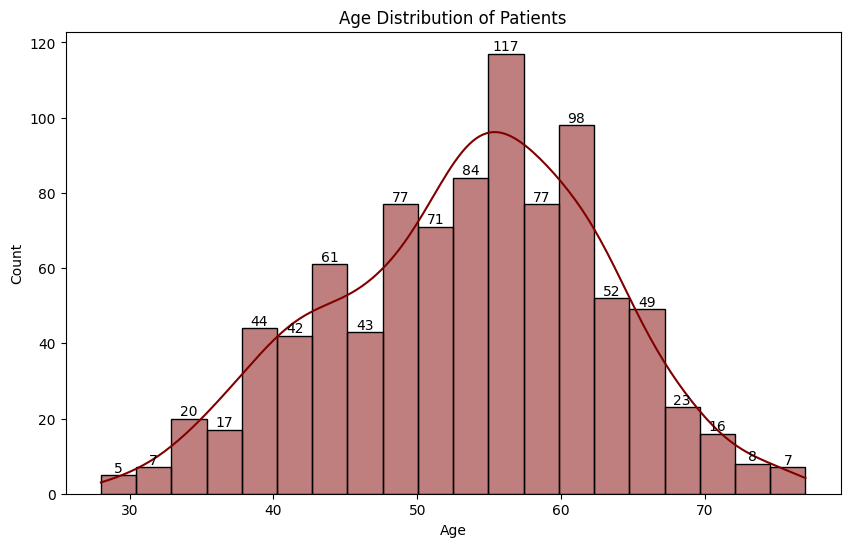

In [13]:
plt.figure(figsize=(10, 6))
ax = sns.histplot(Heart_Disease['Age'], bins=20, kde=True, color='maroon')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

The histogram shows that the patients age follow a ***NORMAL DISTRIBUTION***. The majority of individuals fall between 50 and 60 years old, with the highest single concentration peaking at 117 patients around age 56.

#*CONTINUOUS NUMERICAL FEATURES*
This part helps identify Potential Outliers.

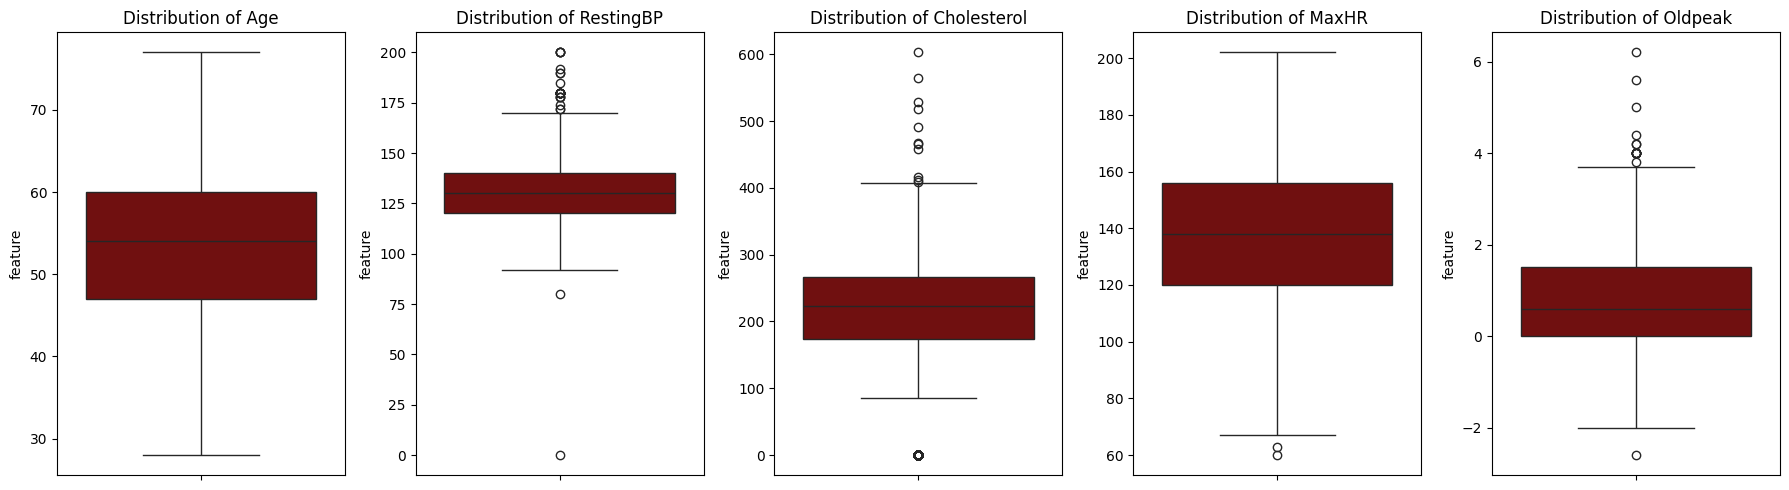

In [14]:
numerical_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
fig, axes = plt.subplots(1, len(numerical_features), figsize=(18, 5))
for i, feature in enumerate(numerical_features):
    sns.boxplot(y=Heart_Disease[feature], color='maroon', ax=axes[i])
    axes[i].set_title(f'Distribution of {feature}', fontsize=12)
    axes[i].set_ylabel('feature')
plt.tight_layout()
plt.show()

**Age**: Well-distributed with a median age around 55 years old, representing a typical middle-aged to older cohort standard in cardiac studies. **RestingBP (Blood Pressure)**: Most patients fall within the normal-to-hypertensive range (120–140 mmHg), but there are visible upper outliers reaching up to 200 mmHg and an anomalous 0 value that likely indicates a data entry error. **Cholesterol**: The bulk of the data lies between 200 and 300 mg/dl. However, there are highly significant upper outliers reaching nearly 600 mg/dl, alongside a cluster of 0 values that likely represent missing data marked as zero. **MaxHR (Maximum Heart Rate)**: Shows a healthy, slightly left-skewed spread with a median around 140 bpm, with only one lower outlier near 60 bpm. **Oldpeak (ST Depression)**: Heavily right-skewed with most values concentrated between 0 and 2. The upper outliers stretching up to 6 indicate patients experiencing severe cardiac stress responses during exercise.

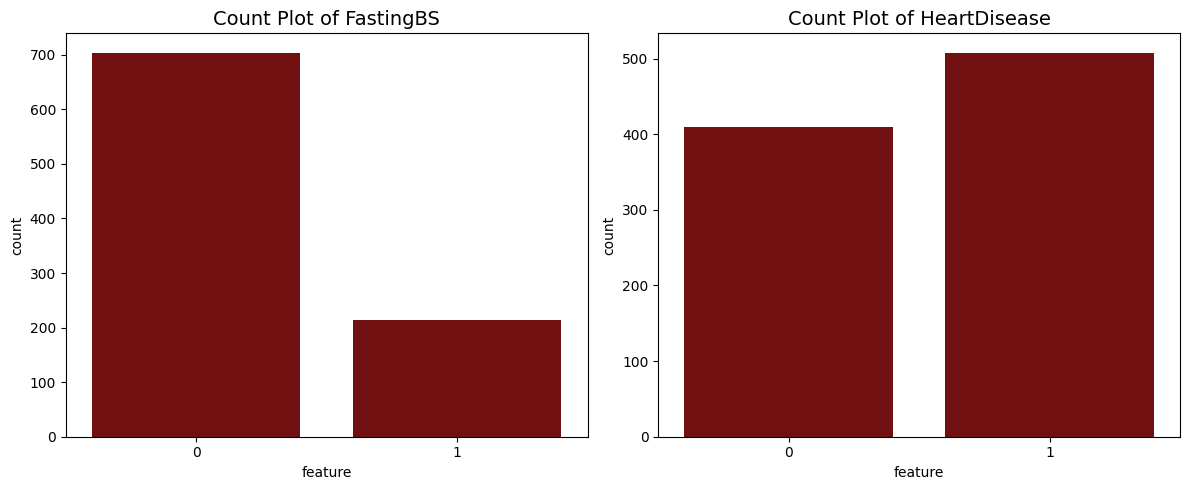

In [15]:
binary_features = ['FastingBS', 'HeartDisease']
fig, axes = plt.subplots(1, len(binary_features), figsize=(12, 5))
for i, feature in enumerate(binary_features):
    sns.countplot(x=Heart_Disease[feature], color='maroon', ax=axes[i])
    axes[i].set_title(f'Count Plot of {feature}', fontsize=14)
    axes[i].set_ylabel('count')
    axes[i].set_xlabel('feature')
plt.tight_layout()
plt.show()

**FastingBS (Fasting Blood Sugar)**: The vast majority of patients (over 700) have a normal fasting blood sugar level under 120 mg/dl (0), while a much smaller number (around 200) have elevated levels (1). **HeartDisease**: The dataset is highly balanced for my target variable, containing a nearly equal split between patients diagnosed without heart disease (0, approx. 410) and with heart disease (1, approx. 508).

#*CHEST PAIN TYPE AND HEART DISEASE*

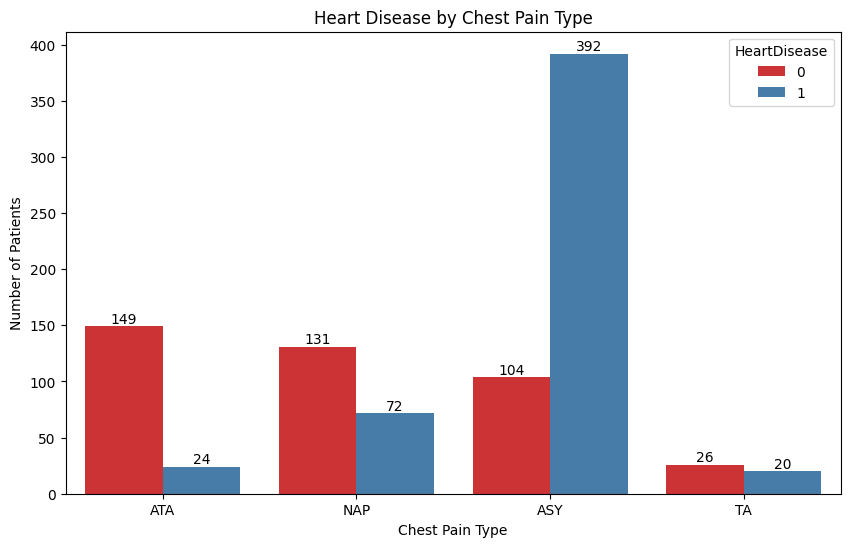

In [16]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='ChestPainType', data=Heart_Disease, hue='HeartDisease', palette='Set1')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Heart Disease by Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.ylabel('Number of Patients')
plt.show()

This chart reveals that asymptomatic chest pain (ASY) is strongly linked to heart disease, making up the vast majority of positive diagnoses (392 cases). Conversely, non-anginal pain (NAP) and atypical angina (ATA) are much more frequently observed in healthy individuals without heart disease.

*AGE VS MAXIMUM HEART RATE*

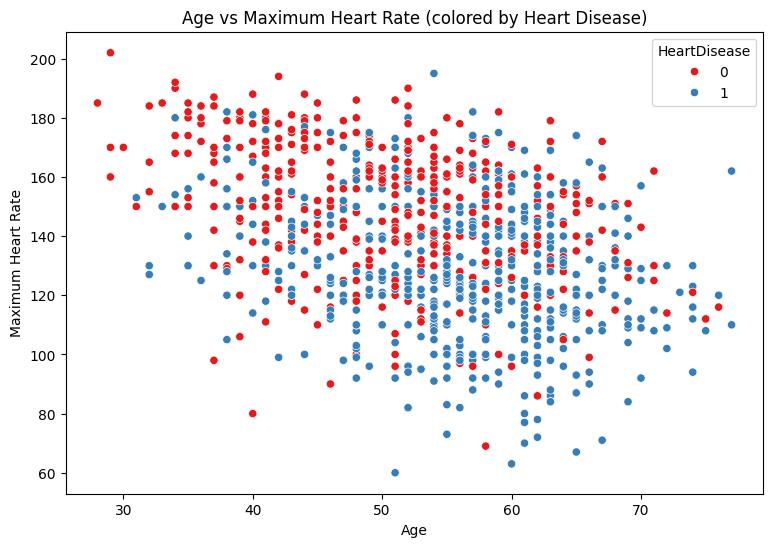

In [17]:
plt.figure(figsize=(9, 6))
sns.scatterplot(x='Age', y='MaxHR', data=Heart_Disease, hue='HeartDisease', palette='Set1')
plt.title('Age vs Maximum Heart Rate (colored by Heart Disease)')
plt.xlabel('Age')
plt.ylabel('Maximum Heart Rate')
plt.show()

The scatter plot demonstrates a clear negative correlation where maximum heart rate naturally declines as patient age increases. Additionally, it highlights that patients diagnosed with heart disease (red dots) tend to cluster around lower maximum heart rates compared to healthy individuals (blue dots) of the same age.

#*CORRELATION HEATMAP*

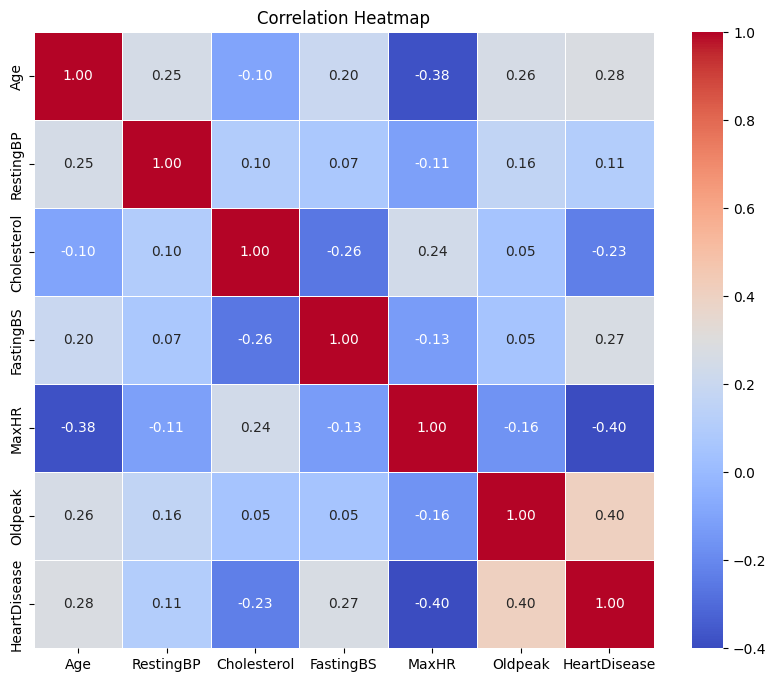

In [18]:
plt.figure(figsize=(10, 8))
numeric_Heart_Disease = Heart_Disease.select_dtypes(include=[np.number])
correlation_matrix = numeric_Heart_Disease.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths= 0.5)
plt.title('Correlation Heatmap')
plt.show()

This heatmap shows that **HeartDisease** has a moderate positive correlation with **Oldpeak** (0.40) and a strong negative correlation with **MaxHR** (-0.40). This indicates that higher exercise-induced ST depression and lower maximum heart rates are the strongest numerical indicators of heart disease in this dataset.

#*NUMERICAL CORRELATION WITH TARGET*

In [19]:
target_correlation = (Heart_Disease.select_dtypes(include=np.number).corr()['HeartDisease']).sort_values(ascending=False)
print(target_correlation)

HeartDisease    1.000000
Oldpeak         0.403951
Age             0.282039
FastingBS       0.267291
RestingBP       0.107589
Cholesterol    -0.232741
MaxHR          -0.400421
Name: HeartDisease, dtype: float64


**Oldpeak (0.40)**: This has the strongest positive link. Higher values (indicating stress during exercise) relate to higher heart disease risk.

**Age (0.28) & FastingBS (0.26)**: Being older or having higher fasting blood sugar both show a moderate positive link to heart disease.

**RestingBP (0.10)**: Higher resting blood pressure has a weak positive link to heart disease.

**Cholesterol (-0.23)**: In this specific dataset, higher cholesterol slightly correlates with lower risk (which might mean other factors are at play, or the data is from treated patients).

**MaxHR (-0.40)**: This has a strong negative link. A higher maximum heart rate during exercise is heavily related to a lower risk of heart disease.

#**OUTLIER DETECTION USING IQR**

In [20]:
def detect_outliers_iqr(data, column):
  Q1 = data[column].quantile(0.25)
  Q3 = data[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
  return outliers, lower_bound, upper_bound

#*Return Outlier Detection for the Continuous Numerical Variables*

In [21]:
continuous_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
for column in continuous_features:
  outliers, lower_bound, upper_bound = detect_outliers_iqr(Heart_Disease, column)
  print(f"Column: {column}")
  print(f"Number of outliers: {len(outliers)}")
  print(f"Lower bound: {lower_bound}")
  print(f"Upper bound: {upper_bound}")

Column: Age
Number of outliers: 0
Lower bound: 27.5
Upper bound: 79.5
Column: RestingBP
Number of outliers: 28
Lower bound: 90.0
Upper bound: 170.0
Column: Cholesterol
Number of outliers: 183
Lower bound: 32.625
Upper bound: 407.625
Column: MaxHR
Number of outliers: 2
Lower bound: 66.0
Upper bound: 210.0
Column: Oldpeak
Number of outliers: 16
Lower bound: -2.25
Upper bound: 3.75


#*Calculate Outlier Percentage*

In [22]:
outlier_percentages = []
for column in continuous_features:
  outliers, lower_bound, upper_bound = detect_outliers_iqr(Heart_Disease, column)
  percentage = (len(outliers) / len(Heart_Disease))*100
  outlier_percentages.append({'feature': column, 'Outliers': len(outliers),'Percentage':percentage})
  outlier_Heart_Disease = pd.DataFrame(outlier_percentages)
  print(outlier_Heart_Disease)

  feature  Outliers  Percentage
0     Age         0         0.0
     feature  Outliers  Percentage
0        Age         0    0.000000
1  RestingBP        28    3.050109
       feature  Outliers  Percentage
0          Age         0    0.000000
1    RestingBP        28    3.050109
2  Cholesterol       183   19.934641
       feature  Outliers  Percentage
0          Age         0    0.000000
1    RestingBP        28    3.050109
2  Cholesterol       183   19.934641
3        MaxHR         2    0.217865
       feature  Outliers  Percentage
0          Age         0    0.000000
1    RestingBP        28    3.050109
2  Cholesterol       183   19.934641
3        MaxHR         2    0.217865
4      Oldpeak        16    1.742919


#**Fixing Outliers in the Cholesterol Column**

In [23]:
Heart_Disease['Cholesterol'] = Heart_Disease['Cholesterol'].replace(0, Heart_Disease[Heart_Disease['Cholesterol'] > 0]['Cholesterol'].median())

#*CHECKING INVALID VALUES*

In [24]:
print('RestingBP values equal to zero:')
print((Heart_Disease['RestingBP'] == 0).sum())
print('Cholesterol values equal to zero:')
print((Heart_Disease['Cholesterol'] == 0).sum())
print('Minimum MaxHR:',Heart_Disease['MaxHR'].min())
print('Maximum MaxHR:',Heart_Disease['MaxHR'].max())
print('Minimum Oldpeak:',Heart_Disease['Oldpeak'].min())
print('Maximum Oldpeak:',Heart_Disease['Oldpeak'].max())


RestingBP values equal to zero:
1
Cholesterol values equal to zero:
0
Minimum MaxHR: 60
Maximum MaxHR: 202
Minimum Oldpeak: -2.6
Maximum Oldpeak: 6.2


#*Fixing Anomalies*

In [25]:
Heart_Disease = Heart_Disease[Heart_Disease['RestingBP'] > 0]
Heart_Disease['Oldpeak'] = Heart_Disease['Oldpeak'].clip(lower=0)

#*RECHECKING INVALID VALUES*

In [26]:
print('RestingBP values equal to zero:')
print((Heart_Disease['RestingBP'] == 0).sum())
print('Cholesterol values equal to zero:')
print((Heart_Disease['Cholesterol'] == 0).sum())
print('Minimum MaxHR:',Heart_Disease['MaxHR'].min())
print('Maximum MaxHR:',Heart_Disease['MaxHR'].max())
print('Minimum Oldpeak:',Heart_Disease['Oldpeak'].min())
print('Maximum Oldpeak:',Heart_Disease['Oldpeak'].max())

RestingBP values equal to zero:
0
Cholesterol values equal to zero:
0
Minimum MaxHR: 60
Maximum MaxHR: 202
Minimum Oldpeak: 0.0
Maximum Oldpeak: 6.2


#**FEATURE ENGINEERING**

   Age    Age_Group
0   40        Young
1   49  Middle-Aged
2   37        Young
3   48  Middle-Aged
4   54  Middle-Aged
5   39        Young
6   45  Middle-Aged
7   54  Middle-Aged
8   37        Young
9   48  Middle-Aged


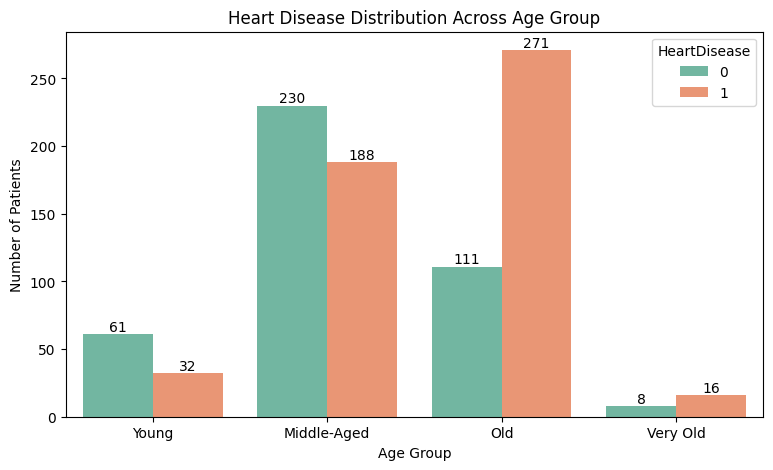

In [27]:
Heart_Disease['Age_Group'] = pd.cut(Heart_Disease['Age'], bins=[0,40,55,70,100], labels=['Young','Middle-Aged','Old','Very Old'])
print(Heart_Disease[['Age','Age_Group']].head(10))
plt.figure(figsize=(9, 5))
ax = sns.countplot(x='Age_Group', data=Heart_Disease, hue='HeartDisease', palette='Set2')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Heart Disease Distribution Across Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.show()


Younger and middle-aged groups have a higher count of patients without heart disease (0) than those with it. Older and very old groups show the opposite trend, with heart disease cases (1) significantly dominating among older patients.


#**IDENTIFYING RELEVANT AND IRRELEVANT FEATURES**

In [28]:
target = 'Heart_Disease'
features = [column for column in Heart_Disease.columns if column not in [target, 'Age Group']]
print(features)

['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease', 'Age_Group']


#**PREPARING X AND y**

In [29]:
X = Heart_Disease.drop(columns=['HeartDisease', 'Age_Group'])
y = Heart_Disease['HeartDisease']
print('Xshape:', X.shape)
print('yshape:', y.shape)

Xshape: (917, 11)
yshape: (917,)


#**TRAIN TEST SPLIT**

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print('Training Data:', X_train.shape)
print('Testing Data:', X_test.shape)

Training Data: (733, 11)
Testing Data: (184, 11)


#**BUILDING NUMERICAL AND CATEGORICAL PREPROCESSING PIPELINE**

In [31]:
numeric_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

#*COMBINE THE PREPROCESSING PIPELINES*

In [32]:
numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
categorical_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS']
preprocessor = ColumnTransformer([('numeric', numeric_pipeline, numeric_features),('categorical', categorical_pipeline, categorical_features)],remainder = 'passthrough')

#*APPLYING PREPROCESSING*

In [33]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print('Processed training shape:', X_train_processed.shape)
print('Processed testing shape:', X_test_processed.shape)

Processed training shape: (733, 21)
Processed testing shape: (184, 21)


#**OBTAIN FEATURE NAMES**

In [34]:
feature_names = preprocessor.get_feature_names_out()
print('Number of final features:', len(feature_names))
print(feature_names)

Number of final features: 21
['numeric__Age' 'numeric__RestingBP' 'numeric__Cholesterol'
 'numeric__MaxHR' 'numeric__Oldpeak' 'categorical__Sex_F'
 'categorical__Sex_M' 'categorical__ChestPainType_ASY'
 'categorical__ChestPainType_ATA' 'categorical__ChestPainType_NAP'
 'categorical__ChestPainType_TA' 'categorical__RestingECG_LVH'
 'categorical__RestingECG_Normal' 'categorical__RestingECG_ST'
 'categorical__ExerciseAngina_N' 'categorical__ExerciseAngina_Y'
 'categorical__ST_Slope_Down' 'categorical__ST_Slope_Flat'
 'categorical__ST_Slope_Up' 'categorical__FastingBS_0'
 'categorical__FastingBS_1']


#**CONVERTING PROCESSED DATA TO DATAFRAMES**

In [35]:
X_train_processed_Heart_Disease = pd.DataFrame(X_train_processed, columns=feature_names, index = X_train.index)
X_test_processed_Heart_Disease = pd.DataFrame(X_test_processed, columns=feature_names, index = X_test.index)
print(X_train_processed_Heart_Disease.head())

     numeric__Age  numeric__RestingBP  numeric__Cholesterol  numeric__MaxHR  \
161     -0.504752           -0.271661             -0.599406       -1.590143   
604      1.505450            0.055941              0.178329        0.557626   
659      0.553249           -0.380862             -0.488301       -0.106230   
793      1.399650           -0.435463              0.178329        1.026231   
140     -0.187351            1.475552              1.604176       -1.668244   

     numeric__Oldpeak  categorical__Sex_F  categorical__Sex_M  \
161         -0.850579                 0.0                 1.0   
604         -0.850579                 0.0                 1.0   
659          1.258994                 0.0                 1.0   
793         -0.658800                 0.0                 1.0   
140          1.546663                 0.0                 1.0   

     categorical__ChestPainType_ASY  categorical__ChestPainType_ATA  \
161                             1.0                            

#**CHECKING PROCESSED DATASET**

In [36]:
print(X_train_processed_Heart_Disease.info())

<class 'pandas.core.frame.DataFrame'>
Index: 733 entries, 161 to 62
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   numeric__Age                    733 non-null    float64
 1   numeric__RestingBP              733 non-null    float64
 2   numeric__Cholesterol            733 non-null    float64
 3   numeric__MaxHR                  733 non-null    float64
 4   numeric__Oldpeak                733 non-null    float64
 5   categorical__Sex_F              733 non-null    float64
 6   categorical__Sex_M              733 non-null    float64
 7   categorical__ChestPainType_ASY  733 non-null    float64
 8   categorical__ChestPainType_ATA  733 non-null    float64
 9   categorical__ChestPainType_NAP  733 non-null    float64
 10  categorical__ChestPainType_TA   733 non-null    float64
 11  categorical__RestingECG_LVH     733 non-null    float64
 12  categorical__RestingECG_Normal  733 non-

This Confirms that there are no Text Columns in my processed dataset. All the 21 columns are now numbers meaning they were successfully encoded.

#*CHECKING MISSING VALUES*

In [37]:
print('Missing values after preprocessing:', X_train_processed_Heart_Disease.isnull().sum().sum())

Missing values after preprocessing: 0


#**FEATURE IMPORTANCE ANALYSIS**

In [39]:
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train_processed_Heart_Disease, y_train)
feature_importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending = False)
print(feature_importances.head(15))

categorical__ST_Slope_Up          0.143932
categorical__ST_Slope_Flat        0.108109
numeric__Oldpeak                  0.095655
numeric__MaxHR                    0.095216
categorical__ChestPainType_ASY    0.088570
numeric__Cholesterol              0.073171
numeric__Age                      0.071231
numeric__RestingBP                0.067246
categorical__ExerciseAngina_N     0.052492
categorical__ExerciseAngina_Y     0.042745
categorical__Sex_F                0.023935
categorical__Sex_M                0.020063
categorical__ChestPainType_ATA    0.019682
categorical__FastingBS_1          0.019053
categorical__FastingBS_0          0.017749
dtype: float64


#**VISUALIZE FEATURE IMPORTANCE**

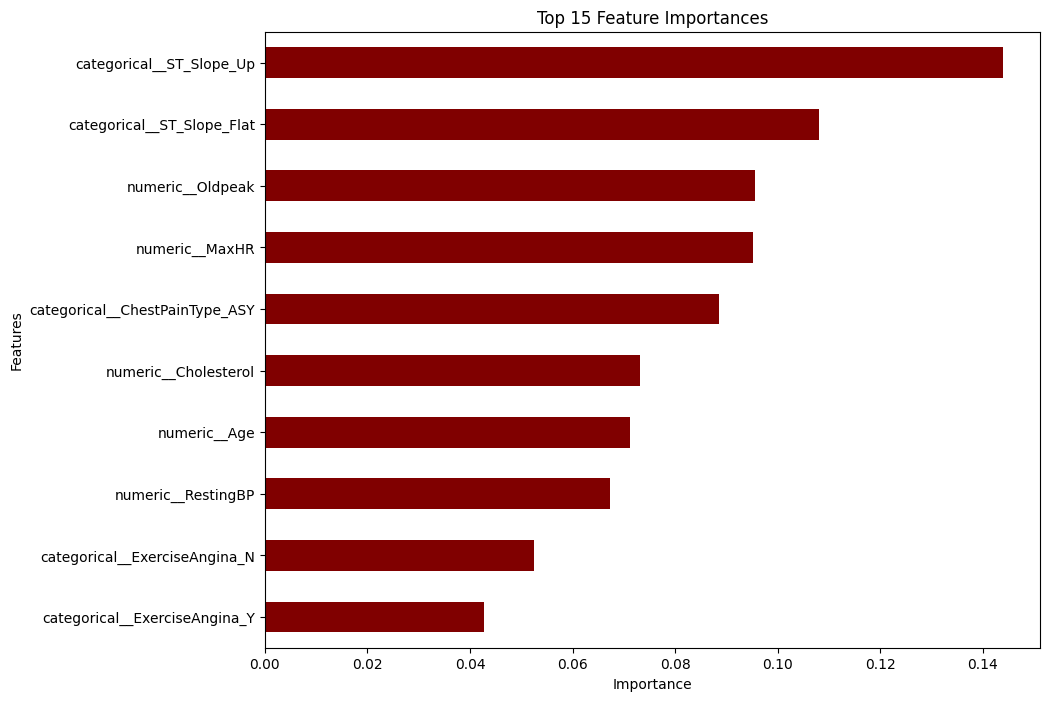

In [40]:
plt.figure(figsize=(10, 8))
feature_importances.head(10).sort_values().plot(kind='barh', color='maroon')
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()


#*Mutual Information Feature Analysis*

In [41]:
mi_scores = mutual_info_classif(X_train_processed_Heart_Disease, y_train, random_state = 42)
mi_scores = pd.Series(mi_scores, index=X_train_processed_Heart_Disease.columns).sort_values(ascending = False)
print(mi_scores.head(15))

categorical__ST_Slope_Up          0.222118
categorical__ST_Slope_Flat        0.136005
categorical__ChestPainType_ASY    0.132667
categorical__ExerciseAngina_Y     0.115353
categorical__ExerciseAngina_N     0.112150
categorical__ChestPainType_ATA    0.094109
numeric__Oldpeak                  0.087854
numeric__Cholesterol              0.084702
categorical__Sex_F                0.075221
numeric__MaxHR                    0.070443
numeric__Age                      0.054285
categorical__Sex_M                0.049226
categorical__FastingBS_1          0.041311
categorical__FastingBS_0          0.031909
categorical__RestingECG_ST        0.030829
dtype: float64


#**Visualize**

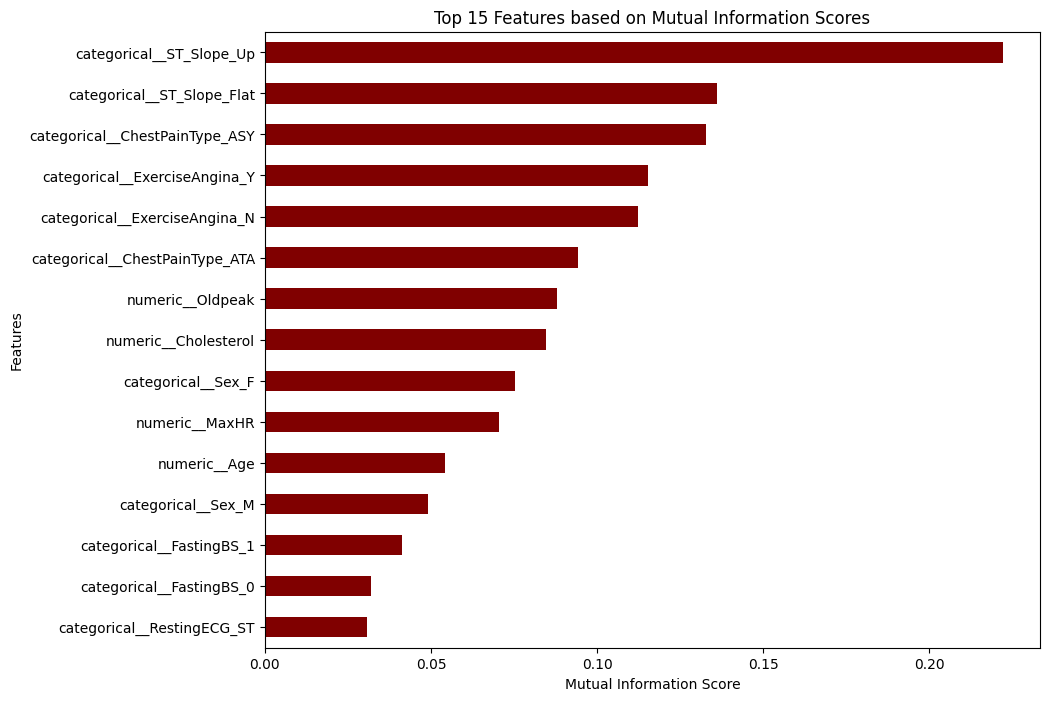

In [43]:
plt.figure(figsize=(10, 8))
mi_scores.head(15).sort_values().plot(kind='barh', color='maroon')
plt.title('Top 15 Features based on Mutual Information Scores')
plt.xlabel('Mutual Information Score')
plt.ylabel('Features')
plt.show()

#**Final Machine Learning Dataset**

In [44]:
X_processed = preprocessor.fit_transform(X)
final_feature_names = preprocessor.get_feature_names_out()
X_processed_Heart_Disease = pd.DataFrame(X_processed, columns=final_feature_names)
final_mi_dataset = pd.concat([X_processed_Heart_Disease. reset_index(drop = True), y. reset_index (drop = True)], axis=1)
print(final_mi_dataset.head())

   numeric__Age  numeric__RestingBP  numeric__Cholesterol  numeric__MaxHR  \
0     -1.432206            0.414627              0.857447        1.383339   
1     -0.478057            1.526360             -1.183717        0.754736   
2     -1.750256           -0.141240              0.745089       -1.523953   
3     -0.584074            0.303453             -0.547024       -1.131075   
4      0.052026            0.970493             -0.902823       -0.581047   

   numeric__Oldpeak  categorical__Sex_F  categorical__Sex_M  \
0         -0.861942                 0.0                 1.0   
1          0.095076                 1.0                 0.0   
2         -0.861942                 0.0                 1.0   
3          0.573584                 1.0                 0.0   
4         -0.861942                 0.0                 1.0   

   categorical__ChestPainType_ASY  categorical__ChestPainType_ATA  \
0                             0.0                             1.0   
1                   

#**CHECKING FINAL DATASET SHAPE**

In [45]:
print(final_mi_dataset.shape)

(917, 22)


#**SAVING CLEANED DATASET**

In [46]:
cleaned_dataset = Heart_Disease.drop(columns=['Age_Group'])
cleaned_dataset.to_csv('Heart_Cleaned.csv', index=False)
print('Cleaned dataset saved as heart_cleaned.csv')


Cleaned dataset saved as heart_cleaned.csv


#**SAVING MACHINE LEARNING DATASET**

In [48]:
cleaned_dataset.to_csv('Heart_ml.csv', index=False)
print('Final ML dataset saved as heart_ml.csv')

Final ML dataset saved as heart_ml.csv
